In [1]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF warnings (1=info, 2=warning, 3=error)

import logging

logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}, GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
tf.get_logger().setLevel('ERROR')  # Set logger to ERROR only

# import sys
# print(sys.executable)

SEED = 42
BATCH_SIZE = 64

H, W = 48, 48
IMG_SIZE = (48, 48)

TensorFlow version: 2.10.1, GPU: True


In [2]:
from tensorflow.keras import layers

DATA_DIR = os.path.join(os.getcwd(), 'data', 'Emotions_dataset')

training_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=SEED, image_size=IMG_SIZE,
    color_mode="grayscale", batch_size=BATCH_SIZE, label_mode="int")

validation_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=SEED, image_size=IMG_SIZE,
    color_mode="grayscale", batch_size=BATCH_SIZE, label_mode="int")

CLASS_NAMES = validation_ds.class_names
NUM_CLASSES = len(validation_ds.class_names)

print('-' * 60)
print(f"Number of classes is {NUM_CLASSES} and classes are {CLASS_NAMES}")

data_augmentation = tf.keras.Sequential([layers.Rescaling(1. / 255),
                                         layers.RandomFlip("horizontal"),
                                         layers.RandomRotation(0.05),
                                         layers.RandomZoom(0.1)])

rescale_only = tf.keras.Sequential([layers.Rescaling(1. / 255)])

AUTOTUNE = tf.data.AUTOTUNE

training_ds = training_ds.shuffle(1000)
training_ds = training_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
training_ds = training_ds.prefetch(AUTOTUNE)

validation_ds = validation_ds.map(lambda x, y: (rescale_only(x), y), num_parallel_calls=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(AUTOTUNE)

for i, (images, labels) in enumerate(training_ds.take(1)):
    print(f"training_ds Batch {i + 1}  image shape {images.shape} and labels shape {labels.shape}")

Found 35887 files belonging to 7 classes.
Using 28710 files for training.
Found 35887 files belonging to 7 classes.
Using 7177 files for validation.
------------------------------------------------------------
Number of classes is 7 and classes are ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
training_ds Batch 1  image shape (64, 48, 48, 1) and labels shape (64,)


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, \
    GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Dropout, MaxPool2D, Multiply, Concatenate, Reshape, Lambda


# Residual Block
def residual_block(x, filters):
    shortcut = x

    # Main path
    x = Conv2D(filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Match channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), padding="same")(shortcut)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x


# Spatial Attention
def spatial_attention(x):
    avg_pool = Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    attention = Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)

    return Multiply()([x, attention])


# Channel Attention
def channel_attention(x, ratio=8):
    channels = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    avg_fc = Dense(channels // ratio, activation='relu')(avg_pool)
    avg_fc = Dense(channels, activation='sigmoid')(avg_fc)

    max_fc = Dense(channels // ratio, activation='relu')(max_pool)
    max_fc = Dense(channels, activation='sigmoid')(max_fc)

    attention = Add()([avg_fc, max_fc])

    attention = Reshape((1, 1, channels))(attention)

    return Multiply()([x, attention])


def create_enhanced_model():
    inputs = Input(shape=(48, 48, 1))

    # Initial feature extractor
    x = Conv2D(32, (3, 3), padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # ---------------- Block 1 ----------------
    x = residual_block(x, 32)
    x = channel_attention(x)
    x = spatial_attention(x)
    x = MaxPool2D()(x)
    x = Dropout(0.2)(x)

    # ---------------- Block 2 ----------------
    x = residual_block(x, 64)
    x = channel_attention(x)
    x = spatial_attention(x)
    x = MaxPool2D()(x)
    x = Dropout(0.25)(x)

    # ---------------- Block 3 ----------------
    x = residual_block(x, 128)
    x = channel_attention(x)
    x = spatial_attention(x)
    x = MaxPool2D()(x)
    x = Dropout(0.3)(x)

    # Global pooling
    x = GlobalAveragePooling2D()(x)

    # Dense classifier
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    outputs = Dense(7, activation='softmax')(x)

    model = Model(inputs, outputs)

    return model


model = create_enhanced_model()

model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 48, 48, 1)]  0           []                               
                                                                                                  
 conv2d_63 (Conv2D)             (None, 48, 48, 32)   320         ['input_8[0][0]']                
                                                                                                  
 batch_normalization_44 (BatchN  (None, 48, 48, 32)  128         ['conv2d_63[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_30 (Activation)     (None, 48, 48, 32)   0           ['batch_normalization_44[0]

In [21]:
# class imbalance handling
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = np.concatenate([y.numpy() for _, y in training_ds])

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: 1.0385992837246318, 1: 9.300291545189504, 2: 1.0008366450533361, 3: 0.572505384063173, 4: 0.8270676691729323, 5: 0.8421824581988853, 6: 1.2701853736229705}


# Focal Loss

In [5]:
class FocalLoss(tf.keras.losses.Loss):

    def __init__(self, gamma=2.0, alpha=0.25,
                 from_logits=False,
                 reduction=tf.keras.losses.Reduction.AUTO,
                 name="focal_loss"):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma  # focusing parameter
        self.alpha = alpha  # class balancing factor
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=self.from_logits)

        pt = tf.exp(-ce)  # probability of the correct class
        focal_loss = self.alpha * tf.pow((1 - pt), self.gamma) * ce

        return focal_loss

In [23]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import CosineDecay

# lr_schedule = CosineDecay(initial_learning_rate=0.001, decay_steps=5000, alpha=0.01)  # End at 0.00001
# optimizer = Adam(learning_rate=lr_schedule)

model.compile(optimizer=Adam(learning_rate=0.001), loss=FocalLoss(gamma=2.0, alpha=0.5), metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1, cooldown=3),
    ModelCheckpoint('emotion_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(training_ds, validation_data=validation_ds, epochs=60,
                    # batch_size=64,    # already what is given in tf method
                    class_weight=class_weights,
                    callbacks=callbacks, verbose=1)

Epoch 1/60
448/449 [============================>.] - ETA: 0s - loss: 0.7325 - accuracy: 0.1901
Epoch 1: val_accuracy improved from -inf to 0.17612, saving model to emotion_model.keras
449/449 [==============================] - 23s 40ms/step - loss: 0.7322 - accuracy: 0.1902 - val_loss: 0.7087 - val_accuracy: 0.1761 - lr: 0.0010
Epoch 2/60
448/449 [============================>.] - ETA: 0s - loss: 0.6563 - accuracy: 0.2689
Epoch 2: val_accuracy improved from 0.17612 to 0.31685, saving model to emotion_model.keras
449/449 [==============================] - 20s 40ms/step - loss: 0.6563 - accuracy: 0.2689 - val_loss: 0.6264 - val_accuracy: 0.3168 - lr: 0.0010
Epoch 3/60
447/449 [============================>.] - ETA: 0s - loss: 0.6243 - accuracy: 0.3054
Epoch 3: val_accuracy did not improve from 0.31685
449/449 [==============================] - 20s 39ms/step - loss: 0.6242 - accuracy: 0.3054 - val_loss: 0.6605 - val_accuracy: 0.2541 - lr: 0.0010
Epoch 4/60
448/449 [======================

In [ ]:
# with only focal loss

In [24]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import CosineDecay

# lr_schedule = CosineDecay(initial_learning_rate=0.001, decay_steps=5000, alpha=0.01)  # End at 0.00001
# optimizer = Adam(learning_rate=lr_schedule)

model.compile(optimizer=Adam(learning_rate=0.001), loss=FocalLoss(gamma=2.0, alpha=0.5), metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1, cooldown=3),
    ModelCheckpoint('emotion_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(training_ds, validation_data=validation_ds, epochs=60,
                    # batch_size=64,    # already what is given in tf method
                    #    class_weight=class_weights,
                    callbacks=callbacks, verbose=1)

Epoch 1/60
448/449 [============================>.] - ETA: 0s - loss: 0.2987 - accuracy: 0.6035
Epoch 1: val_accuracy improved from -inf to 0.58771, saving model to emotion_model.keras
449/449 [==============================] - 24s 43ms/step - loss: 0.2987 - accuracy: 0.6034 - val_loss: 0.3283 - val_accuracy: 0.5877 - lr: 0.0010
Epoch 2/60
448/449 [============================>.] - ETA: 0s - loss: 0.2962 - accuracy: 0.6072
Epoch 2: val_accuracy did not improve from 0.58771
449/449 [==============================] - 23s 45ms/step - loss: 0.2961 - accuracy: 0.6072 - val_loss: 0.3475 - val_accuracy: 0.5720 - lr: 0.0010
Epoch 3/60
449/449 [==============================] - ETA: 0s - loss: 0.2960 - accuracy: 0.6090
Epoch 3: val_accuracy did not improve from 0.58771
449/449 [==============================] - 23s 44ms/step - loss: 0.2960 - accuracy: 0.6090 - val_loss: 0.3378 - val_accuracy: 0.5835 - lr: 0.0010
Epoch 4/60
448/449 [============================>.] - ETA: 0s - loss: 0.2914 - accu

In [12]:
# model.save("data\model.keras")
# model.save("model", save_format="tf")
# model.save('model.h5')

loss, acc = model.evaluate(validation_ds)
print(f"Accuracy: {acc * 100:.2f}%")

from sklearn.metrics import classification_report

y_pred = []
y_true = []

for images, labels in validation_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

113/113 [==============================] - 1s 8ms/step - loss: 0.2771 - accuracy: 0.6597
Accuracy: 65.97%
              precision    recall  f1-score   support

       angry       0.59      0.61      0.60      1004
     disgust       0.81      0.58      0.67       106
        fear       0.56      0.39      0.46      1023
       happy       0.86      0.86      0.86      1825
     neutral       0.53      0.74      0.62      1239
         sad       0.59      0.44      0.51      1207
    surprise       0.70      0.83      0.76       773

    accuracy                           0.66      7177
   macro avg       0.66      0.64      0.64      7177
weighted avg       0.66      0.66      0.65      7177



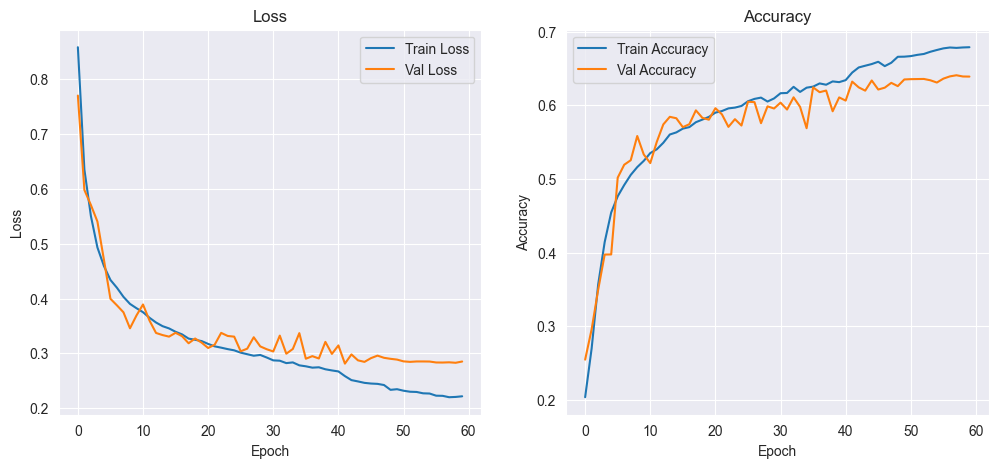

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Confusion Matrix:
 [[ 540    9   65   53  179  123   35]
 [  37   31   15    6    3   10    4]
 [ 122    3  377   56  146  185  134]
 [  33    0   35 1617   88   28   24]
 [  49    1   27  133  877  124   28]
 [ 120    3  106   84  294  591    9]
 [  20    0   87   67   33   14  552]]


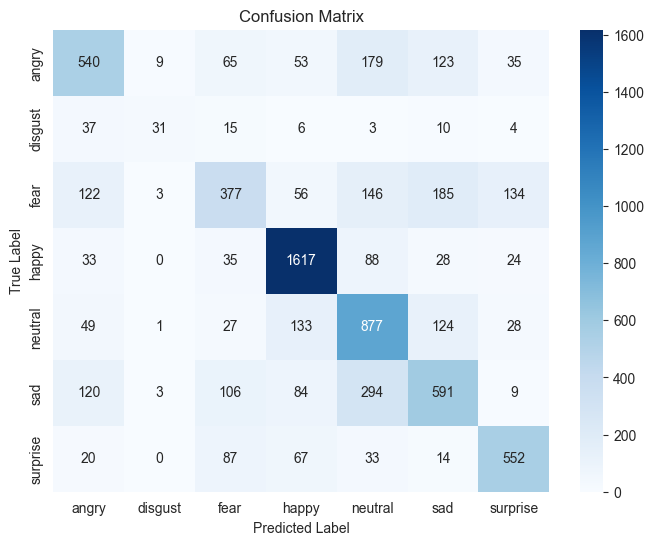

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()